In [ ]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("hr.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
df.shape


(1470, 35)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.reset_index(drop=True, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df.to_csv("HR_Analytics_Cleaned.csv",index=False)

In [ ]:
df.shape

(1470, 35)

--------------------------------------------------------------------------------

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

In [ ]:
df = pd.read_csv("HR_Analytics_Cleaned.csv")

In [ ]:
total_employees = len(df)

print("Total Employees :", total_employees)

Total Employees : 1470


In [ ]:
average_age = round(df["Age"].mean(),2)

print("Average Age :", average_age)

Average Age : 36.92


In [ ]:
average_income = round(df["MonthlyIncome"].mean(),2)

print("Average Monthly Income :", average_income)

Average Monthly Income : 6502.93


In [ ]:
average_experience = round(df["TotalWorkingYears"].mean(),2)

print("Average Working Years :", average_experience)

Average Working Years : 11.28


In [ ]:
kpi = pd.DataFrame({
    "Metric":[
        "Total Employees",
        "Average Age",
        "Average Monthly Income",
        "Average Working Years",

    ],
    "Average Value":[
        total_employees,
        average_age,
        average_income,
        average_experience,

    ]
})

kpi

,Metric,Average Value
0,Total Employees,1470.00
1,Average Age,36.92
2,Average Monthly Income,6502.93
3,Average Working Years,11.28


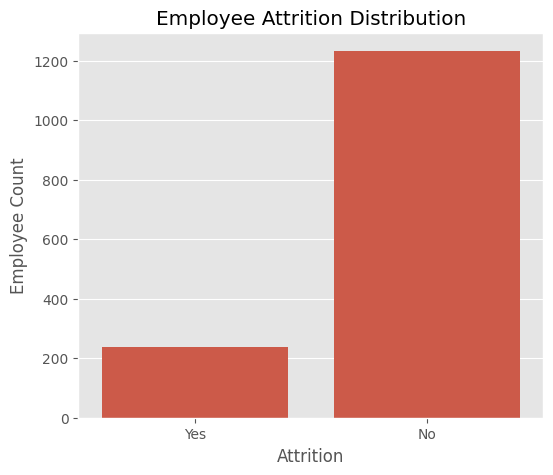

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,
              x="Attrition")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Employee Count")

plt.show()

In [ ]:
attrition_percentage = (
    df["Attrition"]
      .value_counts(normalize=True)
      *100
)

print(attrition_percentage)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


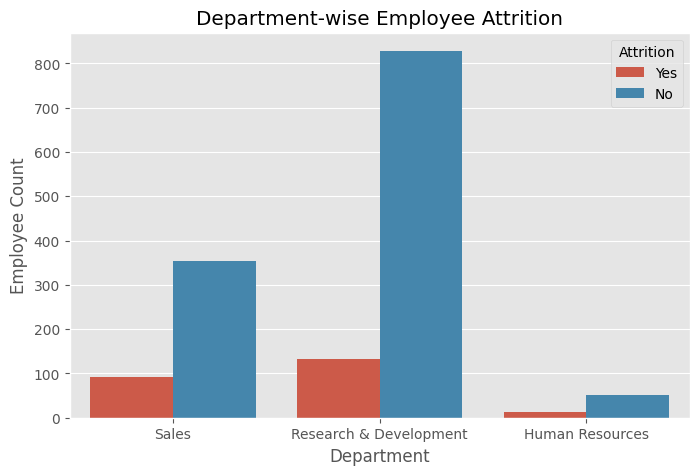

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Department",
    hue="Attrition"
)

plt.title("Department-wise Employee Attrition")
plt.xlabel("Department")
plt.ylabel("Employee Count")
plt.legend(title="Attrition")

plt.show()

In [ ]:
department_attrition_percent = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

department_attrition_percent.round(2)

Attrition,No,Yes
Department,,
Human Resources,80.95,19.05
Research & Development,86.16,13.84
Sales,79.37,20.63


--------------------------------------------------------------------------------

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
df = pd.read_csv("HR_Analytics_Cleaned.csv")

In [ ]:
df_ml = df.copy()

le = LabelEncoder()

for col in df_ml.select_dtypes(include="object").columns:
    df_ml[col] = le.fit_transform(df_ml[col])

In [ ]:
X = df_ml.drop("Attrition", axis=1)
y = df_ml["Attrition"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### **LogisticRegression👇**

In [ ]:
lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [ ]:
y_pred_lr = lr_model.predict(X_test)

y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

In [ ]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1 Score :", f1_lr)
print("ROC-AUC  :", roc_auc_lr)

Accuracy : 0.8741496598639455
Precision: 0.6923076923076923
Recall   : 0.3829787234042553
F1 Score : 0.4931506849315068
ROC-AUC  : 0.8048066155568955


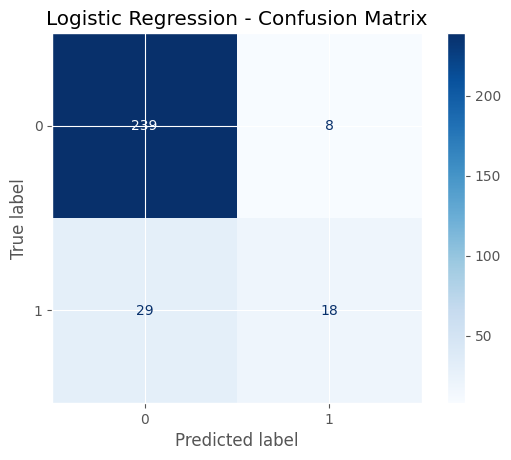

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=lr_model.classes_
)

disp.plot(cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

### **Decision Tree👇**

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test)

y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

In [ ]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)
print("ROC-AUC  :", roc_auc_dt)

Accuracy : 0.7619047619047619
Precision: 0.2909090909090909
Recall   : 0.3404255319148936
F1 Score : 0.3137254901960784
ROC-AUC  : 0.5912653975363942


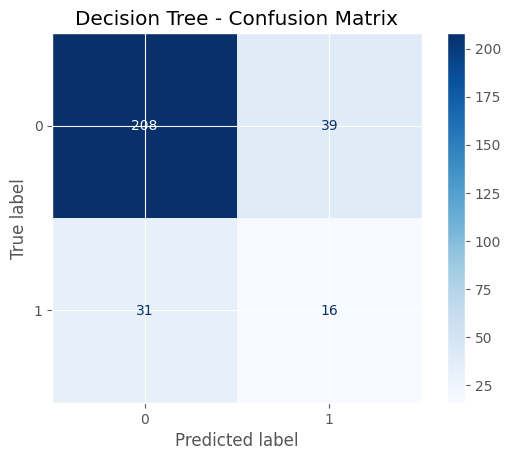

In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dt_model.classes_
)

disp.plot(cmap="Blues")

plt.title("Decision Tree - Confusion Matrix")

plt.show()

### **Random Forest👇**

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)
print("ROC-AUC  :", roc_auc_rf)

Accuracy : 0.8299319727891157
Precision: 0.38461538461538464
Recall   : 0.10638297872340426
F1 Score : 0.16666666666666666
ROC-AUC  : 0.8032991644413817


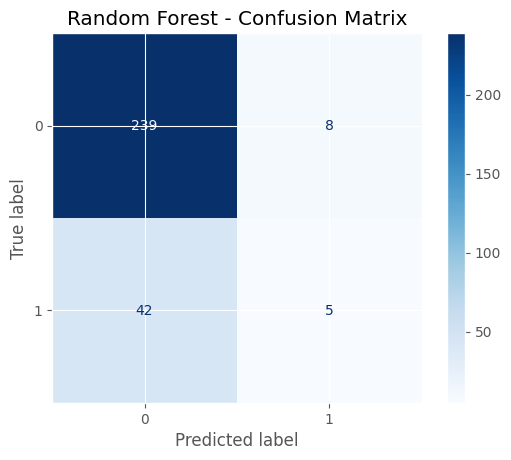

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)

disp.plot(cmap="Blues")

plt.title("Random Forest - Confusion Matrix")

plt.show()

### **XGBoost👇**

In [ ]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [ ]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("Accuracy :", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall   :", recall_xgb)
print("F1 Score :", f1_xgb)
print("ROC-AUC  :", roc_auc_xgb)

Accuracy : 0.8639455782312925
Precision: 0.7058823529411765
Recall   : 0.2553191489361702
F1 Score : 0.375
ROC-AUC  : 0.7759496942027738


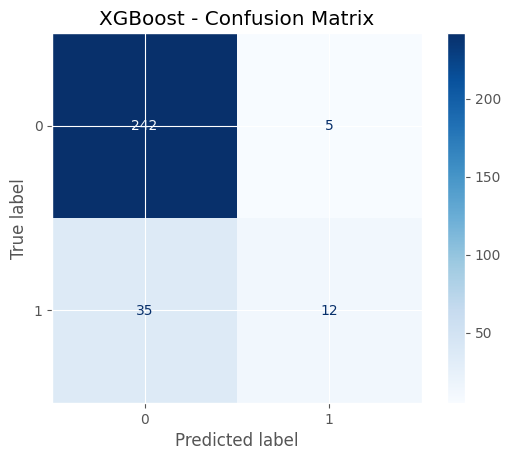

In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=xgb_model.classes_
)

disp.plot(cmap="Blues")

plt.title("XGBoost - Confusion Matrix")

plt.show()

In [ ]:
#Comparison
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf,
        accuracy_xgb
    ],
    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf,
        precision_xgb
    ],
    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf,
        recall_xgb
    ],
    "F1 Score": [
        f1_lr,
        f1_dt,
        f1_rf,
        f1_xgb
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_dt,
        roc_auc_rf,
        roc_auc_xgb
    ]
})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8741,0.6923,0.3830,0.4932,0.8048
1,Decision Tree,0.7619,0.2909,0.3404,0.3137,0.5913
2,Random Forest,0.8299,0.3846,0.1064,0.1667,0.8033
3,XGBoost,0.8639,0.7059,0.2553,0.3750,0.7759


### **Data Dictionary👇**

In [ ]:
import pandas as pd

# Load cleaned dataset
df = pd.read_csv("HR_Analytics_Cleaned.csv")

# Create Data Dictionary
data_dictionary = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

data_dictionary

,Column Name,Data Type,Missing Values,Unique Values
Age,Age,int64,0,43
Attrition,Attrition,object,0,2
BusinessTravel,BusinessTravel,object,0,3
DailyRate,DailyRate,int64,0,886
Department,Department,object,0,3
DistanceFromHome,DistanceFromHome,int64,0,29
Education,Education,int64,0,5
EducationField,EducationField,object,0,6
EmployeeCount,EmployeeCount,int64,0,1
EmployeeNumber,EmployeeNumber,int64,0,1470


### **Data Validation Report👇**

In [ ]:
validation_report = pd.DataFrame({

    "Validation Check":[
        "Total Rows",
        "Total Columns",
        "Missing Values",
        "Duplicate Records",
        "Constant Columns",
        "Numeric Columns",
        "Categorical Columns"
    ],

    "Result":[
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        len(df.columns[df.nunique()==1]),
        len(df.select_dtypes(include=["int64","float64"]).columns),
        len(df.select_dtypes(include=["object"]).columns)
    ]

})

validation_report

,Validation Check,Result
0,Total Rows,1470
1,Total Columns,35
2,Missing Values,0
3,Duplicate Records,0
4,Constant Columns,3
5,Numeric Columns,26
6,Categorical Columns,9


## **Analytics Requirements (Dataset Summary)👇**

In [ ]:
analytics_requirements = pd.DataFrame({

    "Requirement":[

        "Total Employees",
        "Average Age",
        "Average Monthly Income",
        "Average Years At Company",
        "Attrition Rate (%)"

    ],

    "Value":[

        len(df),

        round(df["Age"].mean(),2),

        round(df["MonthlyIncome"].mean(),2),

        round(df["YearsAtCompany"].mean(),2),

        round((df["Attrition"].value_counts(normalize=True)["Yes"])*100,2)

    ]

})

analytics_requirements

,Requirement,Value
0,Total Employees,1470.00
1,Average Age,36.92
2,Average Monthly Income,6502.93
3,Average Years At Company,7.01
4,Attrition Rate (%),16.12


# Feature Engineering

In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

# Feature Engineering
Creating additional features to improve workforce analytics and dashboard insights.

In [ ]:
# 1. Age Group
def age_group(age):
    if age < 30:
        return "Young Adult"
    elif age <= 45:
        return "Middle Aged"
    else:
        return "Senior"

df["Age_Group"] = df["Age"].apply(age_group)


# 2. Experience Level
def experience_level(years):
    if years <= 2:
        return "Fresher"
    elif years <= 5:
        return "Junior"
    elif years <= 10:
        return "Mid-Level"
    else:
        return "Senior"

df["Experience_Level"] = df["TotalWorkingYears"].apply(experience_level)


# 3. Income Category
def income_category(income):
    if income < 4000:
        return "Low Income"
    elif income < 8000:
        return "Medium Income"
    else:
        return "High Income"

df["Income_Category"] = df["MonthlyIncome"].apply(income_category)


# 4. Tenure Group
def tenure_group(years):
    if years <= 2:
        return "New Employee"
    elif years <= 5:
        return "Experienced"
    else:
        return "Long-Term Employee"

df["Tenure_Group"] = df["YearsAtCompany"].apply(tenure_group)

print("✅ Feature Engineering Completed Successfully!")

✅ Feature Engineering Completed Successfully!


In [ ]:
df[[
    "Age",
    "Age_Group",
    "TotalWorkingYears",
    "Experience_Level",
    "MonthlyIncome",
    "Income_Category",
    "YearsAtCompany",
    "Tenure_Group"
]].head(10)

,Age,Age_Group,TotalWorkingYears,Experience_Level,MonthlyIncome,Income_Category,YearsAtCompany,Tenure_Group
0,41,Middle Aged,8,Mid-Level,5993,Medium Income,6,Long-Term Employee
1,49,Senior,10,Mid-Level,5130,Medium Income,10,Long-Term Employee
2,37,Middle Aged,7,Mid-Level,2090,Low Income,0,New Employee
3,33,Middle Aged,8,Mid-Level,2909,Low Income,8,Long-Term Employee
4,27,Young Adult,6,Mid-Level,3468,Low Income,2,New Employee
5,32,Middle Aged,8,Mid-Level,3068,Low Income,7,Long-Term Employee
6,59,Senior,12,Senior,2670,Low Income,1,New Employee
7,30,Middle Aged,1,Fresher,2693,Low Income,1,New Employee
8,38,Middle Aged,10,Mid-Level,9526,High Income,9,Long-Term Employee
9,36,Middle Aged,17,Senior,5237,Medium Income,7,Long-Term Employee


In [ ]:
df.to_csv("HR_Final_Preprocessed.csv", index=False)
print("✅ Final dataset saved as HR_Final_Preprocessed.csv")

✅ Final dataset saved as HR_Final_Preprocessed.csv


In [ ]:
from google.colab import files
files.download("HR_Final_Preprocessed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(df[[
    "Age_Group",
    "Experience_Level",
    "Income_Category",
    "Tenure_Group"
]].head(10))

     Age_Group Experience_Level Income_Category        Tenure_Group
0  Middle Aged        Mid-Level   Medium Income  Long-Term Employee
1       Senior        Mid-Level   Medium Income  Long-Term Employee
2  Middle Aged        Mid-Level      Low Income        New Employee
3  Middle Aged        Mid-Level      Low Income  Long-Term Employee
4  Young Adult        Mid-Level      Low Income        New Employee
5  Middle Aged        Mid-Level      Low Income  Long-Term Employee
6       Senior           Senior      Low Income        New Employee
7  Middle Aged          Fresher      Low Income        New Employee
8  Middle Aged        Mid-Level     High Income  Long-Term Employee
9  Middle Aged           Senior   Medium Income  Long-Term Employee
